## **Projeto de Análise de Series Temporais - 2025**
### **PONTIFICIA UNIVERSIDADE CATÓLICA DE CAMPINAS**
#### **César Henrique Rodrigues de Campos - RA: 23021588**
#### **Gustavo Dorio Santos - RA: 23006995**
#### **Patrick Ferro - RA: 23025769**

## **Importando Bibliotecas importantes**

In [ ]:
# Importando bibliotecas de uso geral
import pandas as pd
import matplotlib as plt

In [3]:
# Importando as classes para análise
from classes.initial_analyses import TimeSeriesExplorer
from classes.forecasting import UniversalForecaster
from classes.noise_analyses import NoiseQualityEvaluator

## **Carregando a base de dados**

In [17]:
# Dataset Energia Industrial
print(100*"=")
print("PROCESSANDO DATASET: ENERGIA")
try:
    df_energia = pd.read_csv('../06_Energia_INT.csv')
    print("Carregamento de dados bem sucedido...")
    # Renomeando coluna críptica para algo legível
    df_energia = df_energia.rename(columns={'IPG2211A2N': 'Producao_Energia', 'DATE': 'data'})

    # Garantindo formato de data
    df_energia['data'] = pd.to_datetime(df_energia['data'])
    print(df_energia.head())
except:
    print("Carregamento de matriculas falhou...")

# Dataset Matrículas Brasil
print(100*"=")
print("ROCESSANDO DATASET: MATRÍCULAS")
try:
    df_matriculas = pd.read_csv('../09_Matriculas_BR.csv')
    print("Carregamento de dados bem sucedido...")
    # Renomeando para padrão
    df_matriculas = df_matriculas.rename(columns={'date': 'data', 'value': 'Total_Matriculas'})
    df_matriculas['data'] = pd.to_datetime(df_matriculas['data'])

    # O dataset de matrículas tem anos pulados (ex: 1983 -> 1986).
    # Para análise temporal correta, precisamos reindexar para frequência ANUAL ('YS')
    # e interpolar os valores faltantes, senão o ARIMA/HoltWinters falhará.
    df_matriculas = df_matriculas.set_index('data').asfreq('YS')
    print(f"Gaps detectados em Matrículas: {df_matriculas['Total_Matriculas'].isnull().sum()}")
    df_matriculas['Total_Matriculas'] = df_matriculas['Total_Matriculas'].interpolate(method='linear')
    df_matriculas = df_matriculas.reset_index() # Reseta para manter compatibilidade com classes
    print(df_matriculas.head())
except:
    print("Carregamento de matriculas falhou...")
print(100*"=")

PROCESSANDO DATASET: ENERGIA
Carregamento de dados bem sucedido...
        data  Producao_Energia
0 2020-11-01           92.9920
1 2020-12-01          112.6681
2 2021-01-01          116.9989
3 2021-02-01          114.1177
4 2021-03-01           98.7179
ROCESSANDO DATASET: MATRÍCULAS
Carregamento de dados bem sucedido...
Gaps detectados em Matrículas: 5
        data  Total_Matriculas
0 1970-01-01          430473.0
1 1971-01-01          569230.0
2 1972-01-01          696215.0
3 1973-01-01          785159.0
4 1974-01-01          954674.0


## **Analisando a série**

Iniciando Análise de Série Temporal...


c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\code\classes\initial_analyses.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='month', y='val', ax=ax3, palette="viridis")


ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 40 must be < 29.

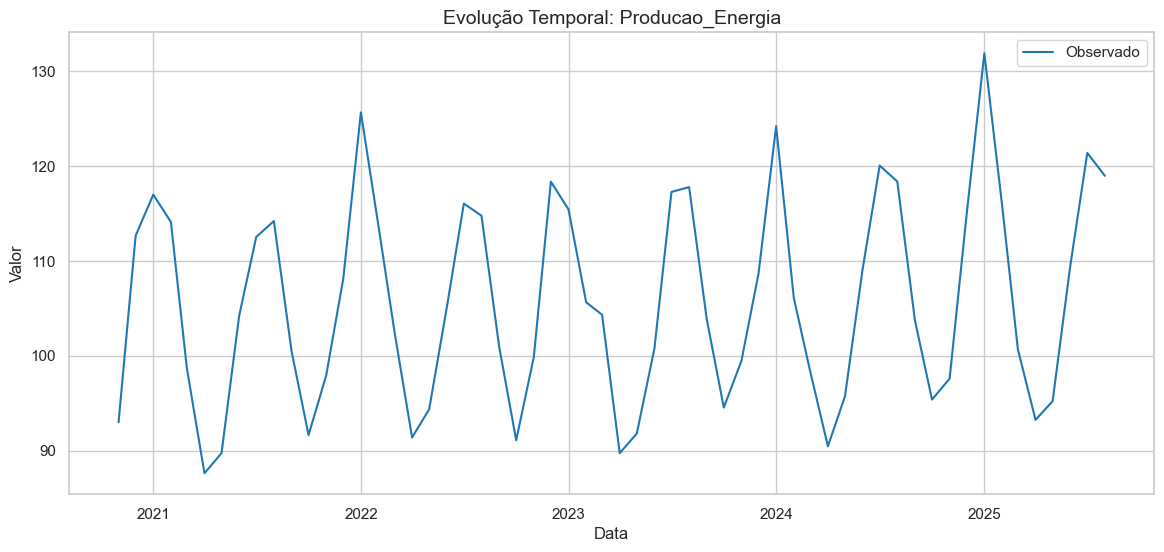

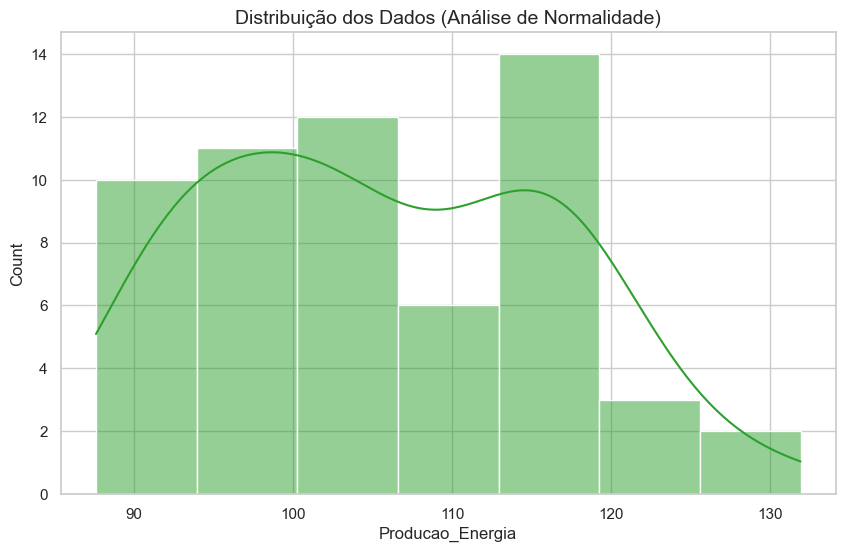

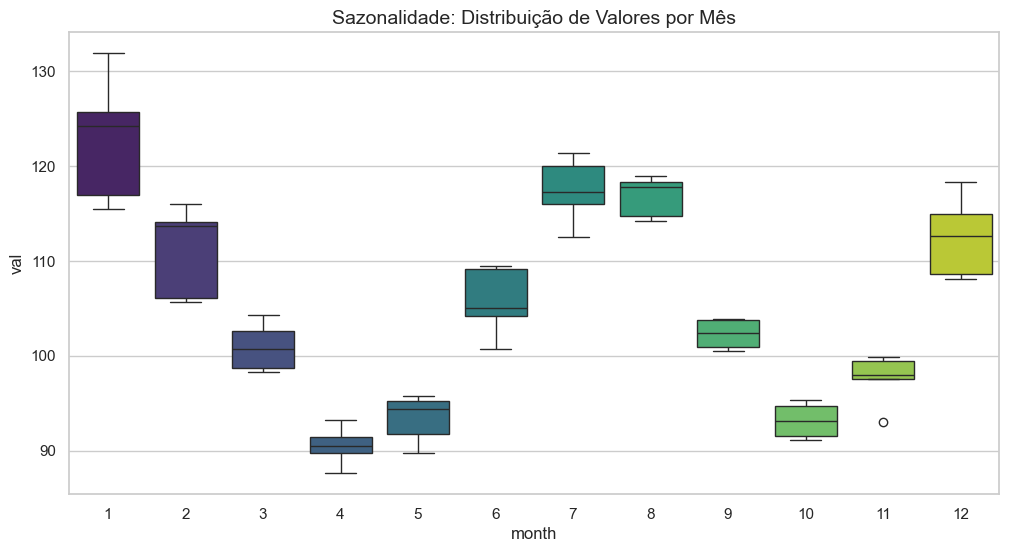

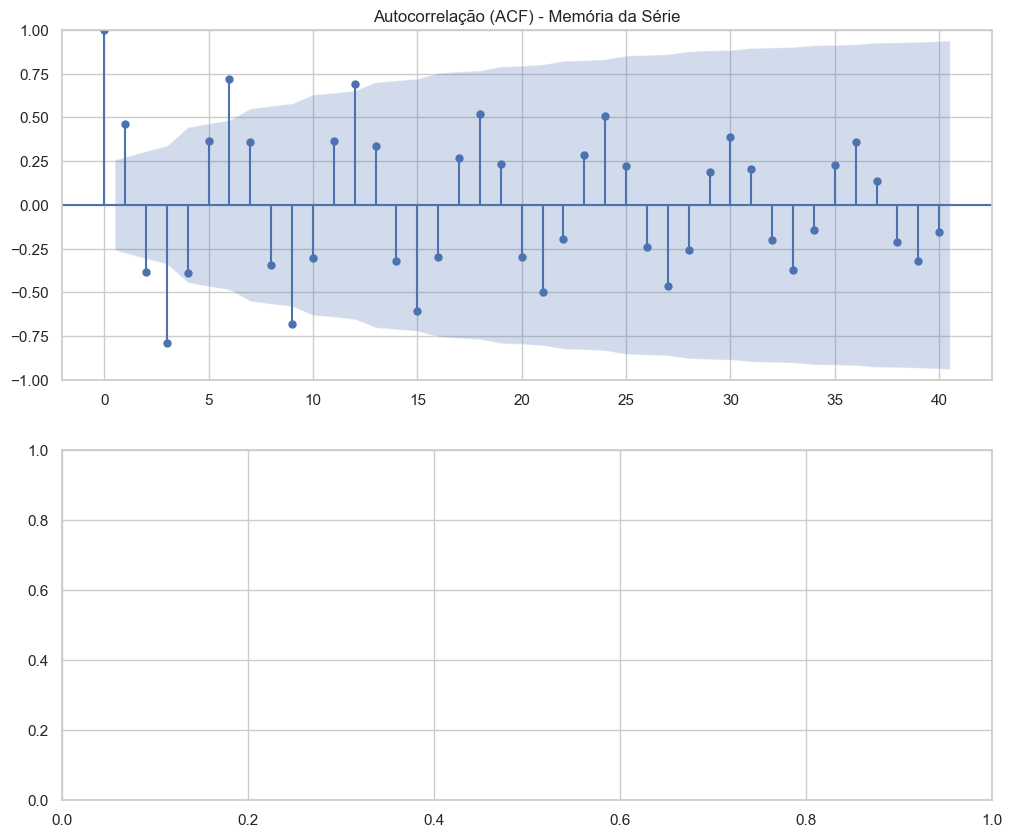

In [18]:
# Explorar
explorer_energy = TimeSeriesExplorer(df_energia, 'data', 'Producao_Energia', freq='MS')
_ = explorer_energy.run_analysis()

Iniciando Análise de Série Temporal...


c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\code\classes\initial_analyses.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='month', y='val', ax=ax3, palette="viridis")


ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 40 must be < 24.

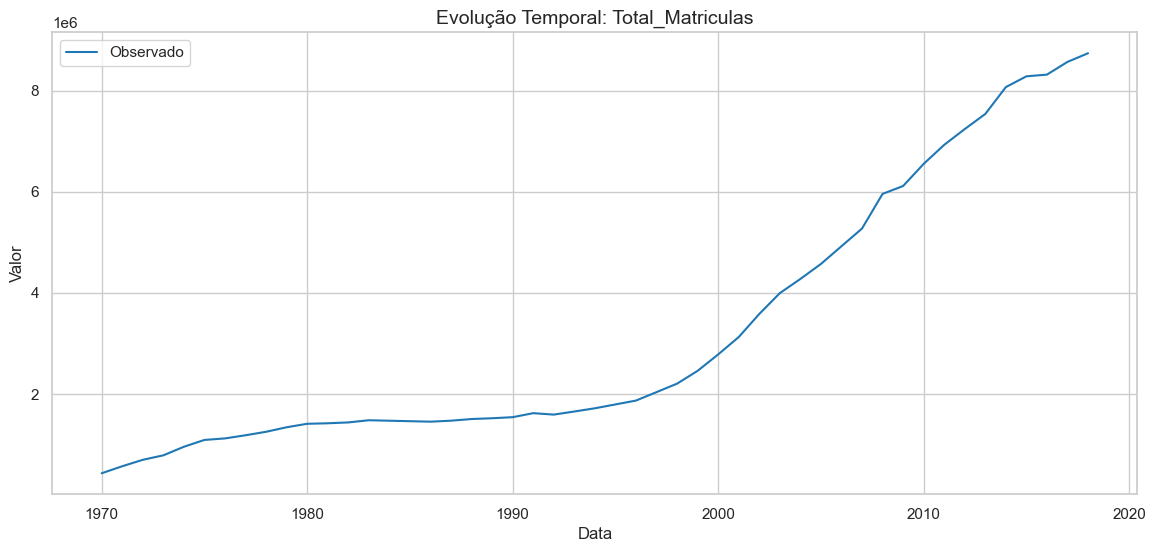

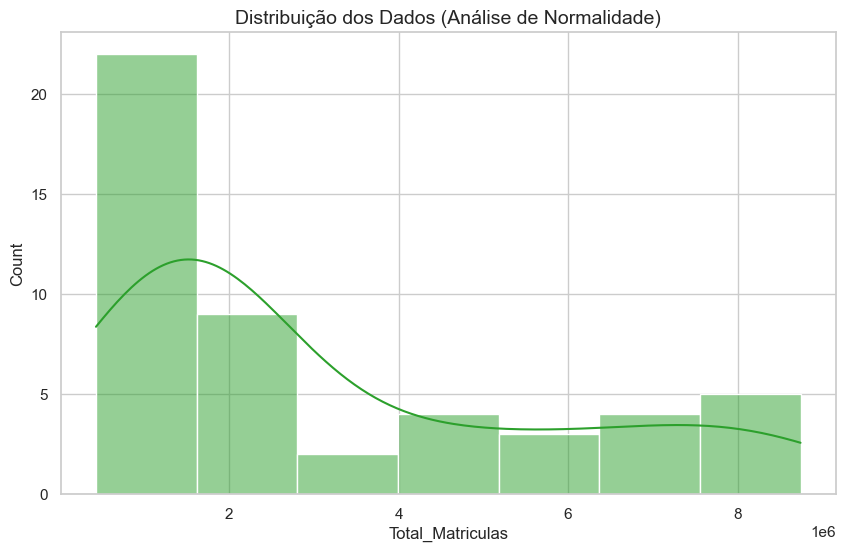

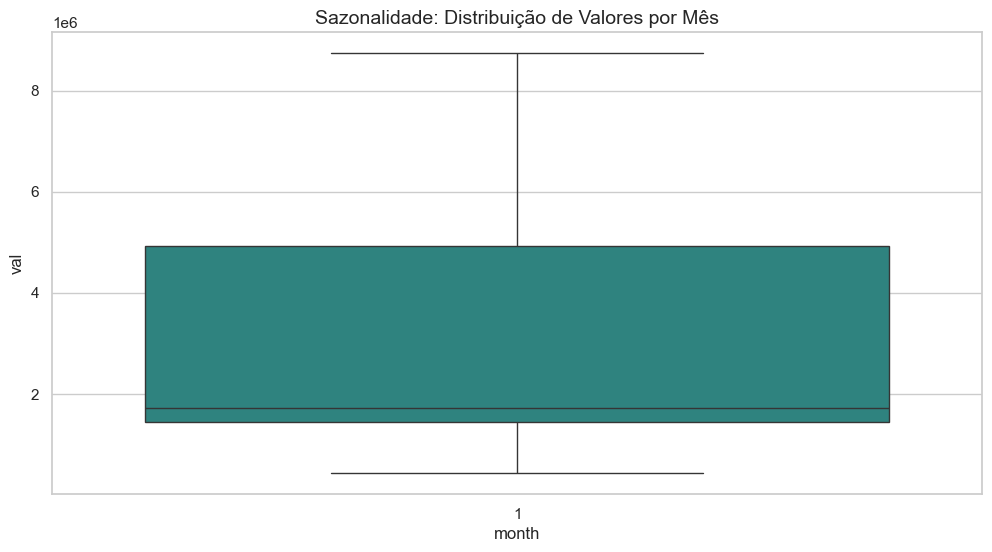

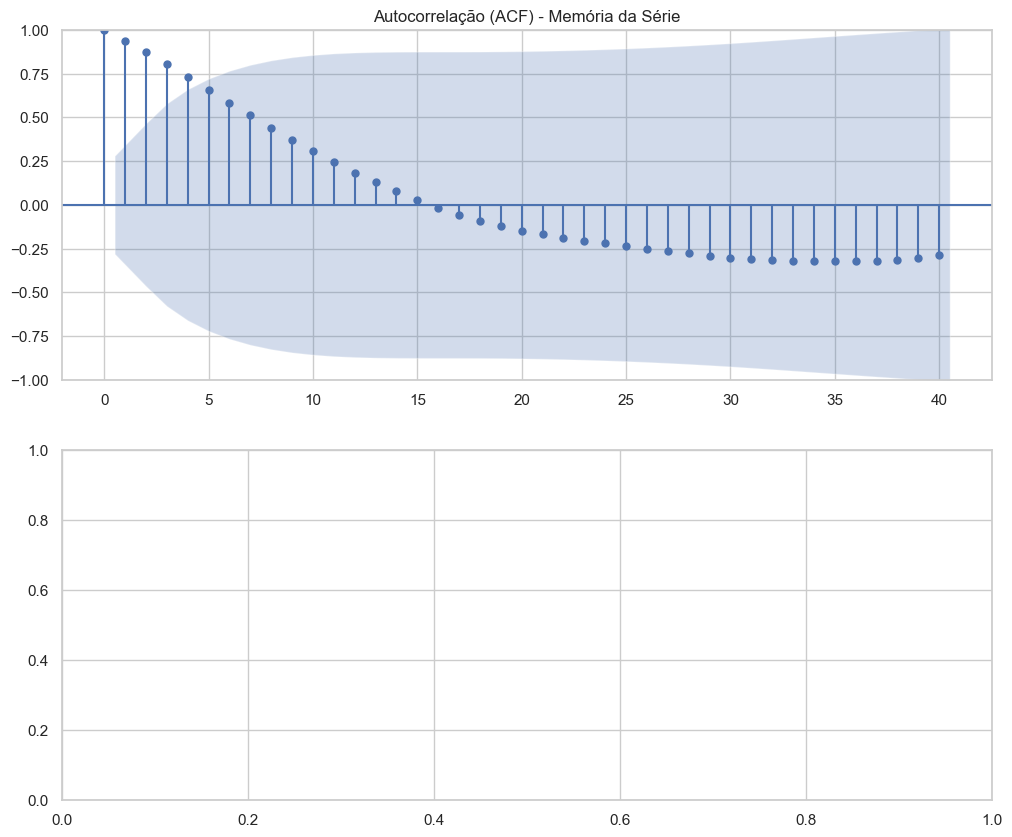

In [19]:
# Explorar
explorer_mat = TimeSeriesExplorer(df_matriculas, 'data', 'Total_Matriculas', freq='YS')
_ = explorer_mat.run_analysis()

## **Aplicando os modelos**

In [20]:
# Prever (Batalha de Modelos)
forecaster_energy = UniversalForecaster(df_energia, 'data', 'Producao_Energia', freq='MS')
forecaster_energy.fit_and_select_best()
forecaster_energy.predict_future(steps=12) # Previsão de 1 ano

c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\code\classes\forecasting.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.df = self.df.asfreq(self.freq).fillna(method='ffill') # Preenchimento simples para evitar erros
c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ayre

Iniciando competição de modelos com Validação Cruzada...
Testando: HoltWinters...
Testando: SARIMA...


08:57:26 - cmdstanpy - INFO - Chain [1] start processing


Testando: DecisionTree...
Testando: Prophet...


08:57:26 - cmdstanpy - INFO - Chain [1] done processing
08:57:26 - cmdstanpy - INFO - Chain [1] start processing
08:57:26 - cmdstanpy - INFO - Chain [1] done processing
08:57:26 - cmdstanpy - INFO - Chain [1] start processing
08:57:26 - cmdstanpy - INFO - Chain [1] done processing



>>> VENCEDOR: HoltWinters (RMSE Médio: 3.55)
Gerando previsão futura de 12 passos com HoltWinters...


{'model': 'HoltWinters',
 'forecast': 2025-09-01    105.140061
 2025-10-01     96.021793
 2025-11-01    101.006420
 2025-12-01    115.993399
 2026-01-01    126.285902
 2026-02-01    114.543541
 2026-03-01    104.354490
 2026-04-01     93.917169
 2026-05-01     96.797913
 2026-06-01    109.162713
 2026-07-01    120.903515
 2026-08-01    120.263020
 Freq: MS, dtype: float64,
 'history': data
 2020-11-01     92.9920
 2020-12-01    112.6681
 2021-01-01    116.9989
 2021-02-01    114.1177
 2021-03-01     98.7179
 2021-04-01     87.6118
 2021-05-01     89.7311
 2021-06-01    104.2213
 2021-07-01    112.5363
 2021-08-01    114.2149
 2021-09-01    100.5376
 2021-10-01     91.6349
 2021-11-01     97.9335
 2021-12-01    108.1238
 2022-01-01    125.6794
 2022-02-01    113.6572
 2022-03-01    102.5691
 2022-04-01     91.3843
 2022-05-01     94.3582
 2022-06-01    105.0858
 2022-07-01    116.0599
 2022-08-01    114.7776
 2022-09-01    100.9932
 2022-10-01     91.0842
 2022-11-01     99.8793
 2022-1

Extraindo componentes e isolando ruído...
Calculando estatísticas de ruído branco...
Calculando Relação Sinal-Ruído (SNR)...
Gerando diagnósticos visuais...


{'metrics': {'white_noise_metrics': {'normality': {'test': 'Shapiro-Wilk',
    'p_value': np.float64(0.7261728470026245),
    'is_gaussian': np.True_},
   'independence': {'test': 'Ljung-Box',
    'p_value': np.float64(0.2049328997415508),
    'is_independent': np.True_},
   'stationarity': {'p_value': np.float64(8.632744780898106e-05),
    'is_stationary': np.True_},
   'moments': {'mean': np.float64(0.06708168402778006),
    'std': np.float64(2.6821341885769807),
    'is_zero_mean': np.True_}},
  'signal_to_noise_ratio_db': np.float64(11.72),
  'interpretation': ['SUCCESS: O ruído segue uma distribuição Normal (Gaussiana).',
   'SUCCESS: O ruído é aleatório (sem correlação serial). Informação bem extraída.']},
 'plot': <Figure size 1500x1200 with 5 Axes>}

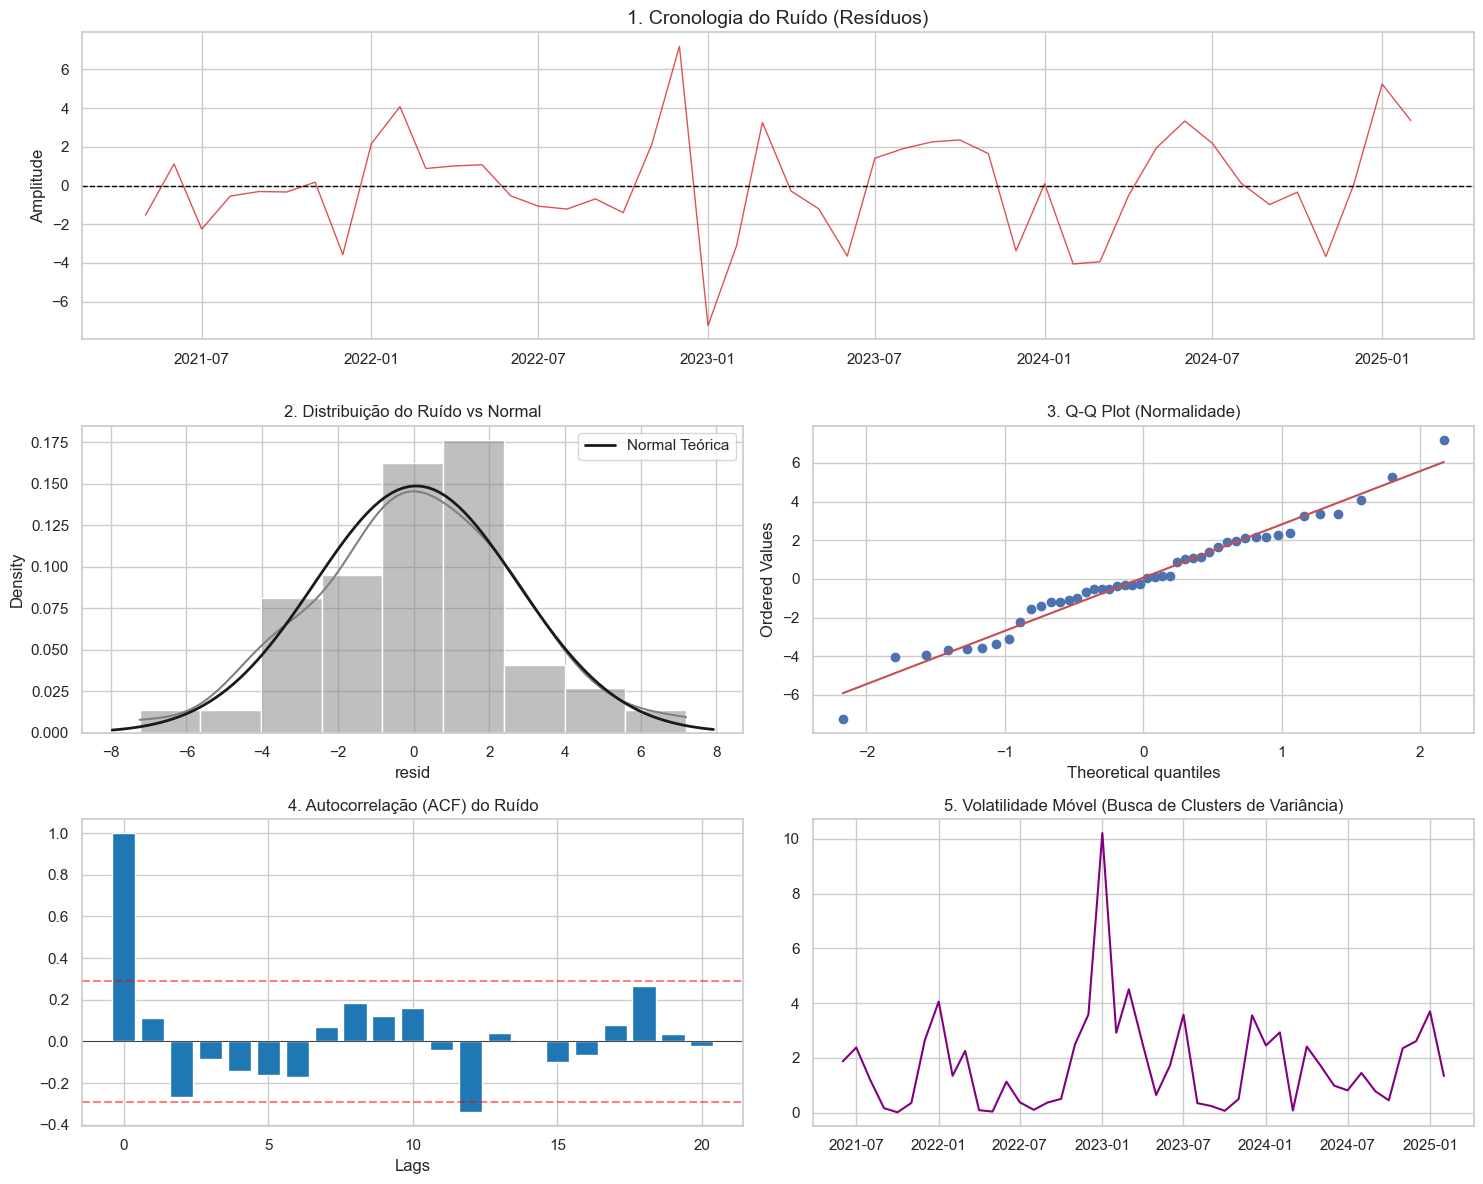

In [21]:
# Avaliar Ruído
noise_energy = NoiseQualityEvaluator(df_energia, 'data', 'Producao_Energia', freq='MS')
noise_energy.run_full_evaluation()

In [22]:
# Prever
forecaster_mat = UniversalForecaster(df_matriculas, 'data', 'Total_Matriculas', freq='YS')
forecaster_mat.fit_and_select_best()
forecaster_mat.predict_future(steps=5) # Previsão de 5 anos

c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\code\classes\forecasting.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.df = self.df.asfreq(self.freq).fillna(method='ffill') # Preenchimento simples para evitar erros
c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
08:58:32 - cmd

Iniciando competição de modelos com Validação Cruzada...
Testando: HoltWinters...
Testando: SARIMA...
Testando: DecisionTree...
Testando: Prophet...


08:58:32 - cmdstanpy - INFO - Chain [1] done processing
08:58:32 - cmdstanpy - INFO - Chain [1] start processing
08:58:32 - cmdstanpy - INFO - Chain [1] done processing
08:58:32 - cmdstanpy - INFO - Chain [1] start processing
08:58:32 - cmdstanpy - INFO - Chain [1] done processing



>>> VENCEDOR: HoltWinters (RMSE Médio: 846208.45)
Gerando previsão futura de 5 passos com HoltWinters...


{'model': 'HoltWinters',
 'forecast': 2019-01-01    8.859876e+06
 2020-01-01    9.047333e+06
 2021-01-01    9.288821e+06
 2022-01-01    9.496592e+06
 2023-01-01    9.607902e+06
 Freq: YS-JAN, dtype: float64,
 'history': data
 1970-01-01     430473.0
 1971-01-01     569230.0
 1972-01-01     696215.0
 1973-01-01     785159.0
 1974-01-01     954674.0
 1975-01-01    1089808.0
 1976-01-01    1119849.0
 1977-01-01    1182411.0
 1978-01-01    1251116.0
 1979-01-01    1340662.0
 1980-01-01    1409243.0
 1981-01-01    1419426.0
 1982-01-01    1436287.0
 1983-01-01    1479397.0
 1984-01-01    1469995.0
 1985-01-01    1460593.0
 1986-01-01    1451191.0
 1987-01-01    1470555.0
 1988-01-01    1503560.0
 1989-01-01    1518904.0
 1990-01-01    1540080.0
 1991-01-01    1619310.0
 1992-01-01    1591176.0
 1993-01-01    1652333.0
 1994-01-01    1716263.0
 1995-01-01    1792396.0
 1996-01-01    1868529.0
 1997-01-01    2036064.0
 1998-01-01    2203599.0
 1999-01-01    2456961.0
 2000-01-01    2781328.0


In [23]:
# Avaliar Ruído
noise_mat = NoiseQualityEvaluator(df_matriculas, 'data', 'Total_Matriculas', freq='YS')
noise_mat.run_full_evaluation()

Extraindo componentes e isolando ruído...
Calculando estatísticas de ruído branco...


c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\ayres\OneDrive\Área de Trabalho\Trabalho Miro\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


ValueError: Invalid input, x is constant

## **Conclusões finais**